In [1]:
import random, os, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, f1_score, accuracy_score
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

PREPROCESSED_DIR = "/kaggle/input/datasets/iftekharuddin27/preprocessed-datasets"
MODELS_DIR       = "/kaggle/input/datasets/iftekharuddin27/transformer-learning"
OUTPUT_DIR       = "/kaggle/working/"
MODEL_NAME       = "xlm-roberta-base"
MAX_LEN          = 128
device           = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES      = {0: 'Non-hateful', 1: 'Hateful', 2: 'Sarcastic'}
print(f"Device: {device}")

Device: cuda


In [2]:
en_test  = pd.read_csv(f"{PREPROCESSED_DIR}/en_test.csv")
bn_test  = pd.read_csv(f"{PREPROCESSED_DIR}/bn_test.csv")
bn_train = pd.read_csv(f"{PREPROCESSED_DIR}/bn_train.csv")

for df in [en_test, bn_test, bn_train]:
    df['text_clean'] = df['text_clean'].fillna('')

def add_aux_labels(df, label_col):
    df['is_hateful']   = (df[label_col] == 1).astype(int)
    df['is_sarcastic'] = (df[label_col] == 2).astype(int)
    return df

en_test  = add_aux_labels(en_test,  'class')
bn_test  = add_aux_labels(bn_test,  'label')
bn_train = add_aux_labels(bn_train, 'label')

print(f"English test : {len(en_test):,}")
print(f"Bangla  test : {len(bn_test):,}")
print(f"Bangla  train: {len(bn_train):,}")

English test : 10,432
Bangla  test : 8,377
Bangla  train: 67,009


In [3]:
class SharedDualHeadModel(nn.Module):
    def __init__(self, model_name, num_classes=3, dropout=0.3):
        super().__init__()
        self.encoder  = AutoModel.from_pretrained(model_name)
        hidden_size   = self.encoder.config.hidden_size
        self.dropout  = nn.Dropout(dropout)
        self.hate_head = nn.Sequential(
            nn.Linear(hidden_size, 256), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(256, 1))
        self.sarcasm_head = nn.Sequential(
            nn.Linear(hidden_size, 256), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(256, 1))
        self.fusion_mlp = nn.Sequential(
            nn.Linear(hidden_size + 256 + 256, 512), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes))

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        out   = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls   = self.dropout(out.last_hidden_state[:, 0, :])
        hh    = self.dropout(F.relu(self.hate_head[0](cls)))
        sh    = self.dropout(F.relu(self.sarcasm_head[0](cls)))
        fused = torch.cat([cls, hh, sh], dim=1)
        return self.fusion_mlp(fused), self.hate_head[3](hh).squeeze(-1), \
               self.sarcasm_head[3](sh).squeeze(-1)


class DualHeadDataset(Dataset):
    def __init__(self, texts, labels_3class, labels_hate,
                 labels_sarc, tokenizer, max_len=128):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True,
            max_length=max_len, return_tensors='pt')
        self.labels_3class = torch.tensor(labels_3class, dtype=torch.long)
        self.labels_hate   = torch.tensor(labels_hate,   dtype=torch.float)
        self.labels_sarc   = torch.tensor(labels_sarc,   dtype=torch.float)

    def __len__(self): return len(self.labels_3class)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels_3class'] = self.labels_3class[idx]
        item['labels_hate']   = self.labels_hate[idx]
        item['labels_sarc']   = self.labels_sarc[idx]
        return item


def run_inference(model, tokenizer, test_df, label_col, name):
    ds     = DualHeadDataset(
        test_df['text_clean'].values, test_df[label_col].values,
        test_df['is_hateful'].values, test_df['is_sarcastic'].values,
        tokenizer, MAX_LEN)
    loader = DataLoader(ds, batch_size=64, shuffle=False)
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            logits, _, _ = model(ids, mask)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(batch['labels_3class'].numpy())
            all_probs.extend(probs)
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro')
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(f"Accuracy : {acc:.4f}  |  Macro F1 : {f1:.4f}")
    print(classification_report(all_labels, all_preds,
                                target_names=list(CLASS_NAMES.values())))
    np.save(f"{OUTPUT_DIR}preds_6D_{name.replace(' ','_')}.npy", all_preds)
    np.save(f"{OUTPUT_DIR}probs_6D_{name.replace(' ','_')}.npy", all_probs)
    return acc, f1

In [4]:
print("Loading English-trained dual-head model...")
tok_en   = AutoTokenizer.from_pretrained(f"{MODELS_DIR}/dualhead_xlmr_English")
model_en = SharedDualHeadModel(MODEL_NAME).to(device)
model_en.load_state_dict(torch.load(
    f"{MODELS_DIR}/dualhead_xlmr_English/model.pt", map_location=device))

acc_e2b, f1_e2b = run_inference(
    model_en, tok_en, bn_test, 'label',
    "Exp1: EN-model zero-shot on BN-test")

print(f"\nBanglaBERT baseline (full BN training) : 0.8200")
print(f"EN model zero-shot on BN               : {f1_e2b:.4f}")
print(f"Gap                                    : {f1_e2b - 0.8200:+.4f}")

Loading English-trained dual-head model...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Exp1: EN-model zero-shot on BN-test
Accuracy : 0.2824  |  Macro F1 : 0.2633
              precision    recall  f1-score   support

 Non-hateful       0.51      0.14      0.22      4140
     Hateful       0.61      0.14      0.23      2560
   Sarcastic       0.22      0.86      0.34      1677

    accuracy                           0.28      8377
   macro avg       0.44      0.38      0.26      8377
weighted avg       0.48      0.28      0.25      8377


BanglaBERT baseline (full BN training) : 0.8200
EN model zero-shot on BN               : 0.2633
Gap                                    : -0.5567


In [5]:
print("Loading Bangla-trained dual-head model...")
tok_bn   = AutoTokenizer.from_pretrained(f"{MODELS_DIR}/dualhead_xlmr_Bangla")
model_bn = SharedDualHeadModel(MODEL_NAME).to(device)
model_bn.load_state_dict(torch.load(
    f"{MODELS_DIR}/dualhead_xlmr_Bangla/model.pt", map_location=device))

acc_b2e, f1_b2e = run_inference(
    model_bn, tok_bn, en_test, 'class',
    "Exp2: BN-model zero-shot on EN-test")

print(f"\nBERT baseline (full EN training) : 0.9029")
print(f"BN model zero-shot on EN         : {f1_b2e:.4f}")
print(f"Gap                              : {f1_b2e - 0.9029:+.4f}")

del model_bn; gc.collect(); torch.cuda.empty_cache()

Loading Bangla-trained dual-head model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Exp2: BN-model zero-shot on EN-test
Accuracy : 0.4064  |  Macro F1 : 0.3346
              precision    recall  f1-score   support

 Non-hateful       0.36      0.93      0.51      3470
     Hateful       0.83      0.18      0.30      3486
   Sarcastic       0.59      0.11      0.19      3476

    accuracy                           0.41     10432
   macro avg       0.59      0.41      0.33     10432
weighted avg       0.60      0.41      0.33     10432


BERT baseline (full EN training) : 0.9029
BN model zero-shot on EN         : 0.3346
Gap                              : -0.5683


In [6]:
# Sample 10% per class from Bangla train
bn_few = bn_train.groupby('label', group_keys=False).apply(
    lambda x: x.sample(frac=0.10, random_state=42)
).reset_index(drop=True)
print(f"Few-shot samples: {len(bn_few):,}  "
      f"dist={bn_few['label'].value_counts().to_dict()}")

# Load English model for fine-tuning
model_few = SharedDualHeadModel(MODEL_NAME).to(device)
model_few.load_state_dict(torch.load(
    f"{MODELS_DIR}/dualhead_xlmr_English/model.pt", map_location=device))

few_ds     = DualHeadDataset(
    bn_few['text_clean'].values, bn_few['label'].values,
    bn_few['is_hateful'].values, bn_few['is_sarcastic'].values,
    tok_en, MAX_LEN)
few_loader = DataLoader(few_ds, batch_size=16, shuffle=True)

optimizer = torch.optim.AdamW(model_few.parameters(), lr=1e-5, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer, 0, len(few_loader) * 3)
crit_3 = nn.CrossEntropyLoss()
crit_b = nn.BCEWithLogitsLoss()

print("\nFine-tuning 3 epochs on few-shot Bangla...")
for epoch in range(3):
    model_few.train()
    total_loss = 0
    for batch in few_loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        l3   = batch['labels_3class'].to(device)
        lh   = batch['labels_hate'].to(device)
        ls   = batch['labels_sarc'].to(device)
        optimizer.zero_grad()
        logits, hl, sl = model_few(ids, mask)
        loss = (0.3*crit_b(hl,lh) + 0.3*crit_b(sl,ls) + 0.4*crit_3(logits,l3))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_few.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += loss.item()
    print(f"  Epoch {epoch+1}/3 — Loss: {total_loss/len(few_loader):.4f}")

acc_few, f1_few = run_inference(
    model_few, tok_en, bn_test, 'label',
    "Exp3: EN-model few-shot-BN on BN-test")

print(f"\nComparison (Bangla test):")
print(f"  BanglaBERT full training : 0.8200")
print(f"  EN model zero-shot       : {f1_e2b:.4f}")
print(f"  EN model few-shot (10%)  : {f1_few:.4f}")

del model_few; gc.collect(); torch.cuda.empty_cache()

Few-shot samples: 6,701  dist={0: 3312, 1: 2048, 2: 1341}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Fine-tuning 3 epochs on few-shot Bangla...
  Epoch 1/3 — Loss: 0.5414
  Epoch 2/3 — Loss: 0.3860
  Epoch 3/3 — Loss: 0.3329

Exp3: EN-model few-shot-BN on BN-test
Accuracy : 0.7641  |  Macro F1 : 0.7332
              precision    recall  f1-score   support

 Non-hateful       0.78      0.79      0.78      4140
     Hateful       0.82      0.88      0.85      2560
   Sarcastic       0.63      0.52      0.57      1677

    accuracy                           0.76      8377
   macro avg       0.74      0.73      0.73      8377
weighted avg       0.76      0.76      0.76      8377


Comparison (Bangla test):
  BanglaBERT full training : 0.8200
  EN model zero-shot       : 0.2633
  EN model few-shot (10%)  : 0.7332



PHASE 6D — TRANSFER LEARNING RESULTS
                Experiment    Test     F1     Gap      Type
BanglaBERT (full BN train)  Bangla 0.8200  0.0000  Baseline
      BERT (full EN train) English 0.9029  0.0000  Baseline
 EN model → BN (zero-shot)  Bangla 0.2633 -0.5567 Zero-shot
 BN model → EN (zero-shot) English 0.3346 -0.5683 Zero-shot
  EN+few-shot BN(10%) → BN  Bangla 0.7332 -0.0868  Few-shot


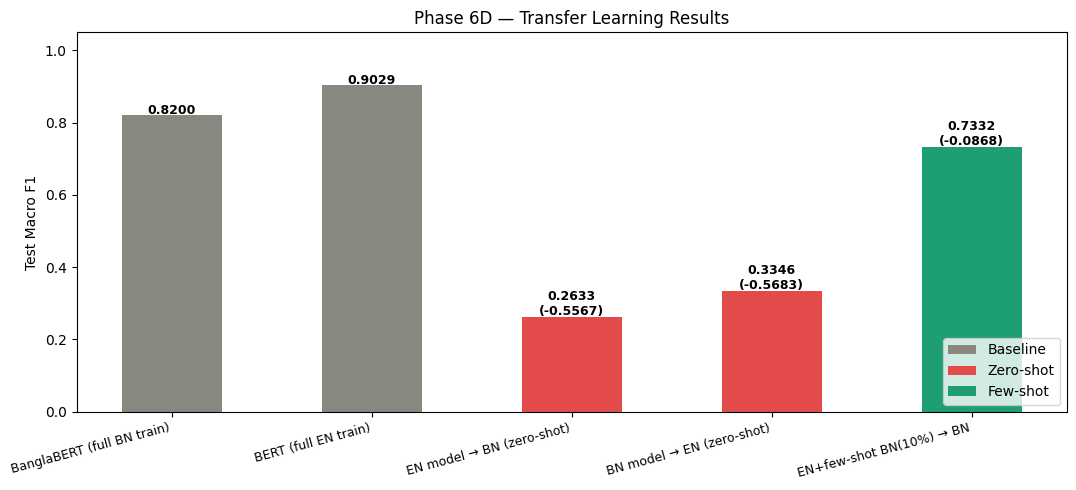

Saved: phase6d_transfer_results.csv + phase6d_chart.png


In [7]:
tl = pd.DataFrame([
    {'Experiment':'BanglaBERT (full BN train)', 'Test':'Bangla',
     'F1':0.8200, 'Gap':0.0,                   'Type':'Baseline'},
    {'Experiment':'BERT (full EN train)',        'Test':'English',
     'F1':0.9029, 'Gap':0.0,                   'Type':'Baseline'},
    {'Experiment':'EN model → BN (zero-shot)',  'Test':'Bangla',
     'F1':round(f1_e2b,4), 'Gap':round(f1_e2b-0.8200,4), 'Type':'Zero-shot'},
    {'Experiment':'BN model → EN (zero-shot)',  'Test':'English',
     'F1':round(f1_b2e,4), 'Gap':round(f1_b2e-0.9029,4), 'Type':'Zero-shot'},
    {'Experiment':'EN+few-shot BN(10%) → BN',  'Test':'Bangla',
     'F1':round(f1_few,4), 'Gap':round(f1_few-0.8200,4), 'Type':'Few-shot'},
])

print("\n" + "="*65)
print("PHASE 6D — TRANSFER LEARNING RESULTS")
print("="*65)
print(tl.to_string(index=False))
tl.to_csv(f"{OUTPUT_DIR}phase6d_transfer_results.csv", index=False)

colors = {'Baseline':'#888780','Zero-shot':'#E24B4A','Few-shot':'#1D9E75'}
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(range(len(tl)), tl['F1'],
              color=[colors[t] for t in tl['Type']], width=0.5)
for bar, val, gap in zip(bars, tl['F1'], tl['Gap']):
    lbl = f"{val:.4f}" + (f"\n({gap:+.4f})" if gap != 0 else "")
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            lbl, ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(tl)))
ax.set_xticklabels(tl['Experiment'], rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Test Macro F1'); ax.set_ylim(0, 1.05)
ax.set_title('Phase 6D — Transfer Learning Results')
ax.legend(handles=[Patch(facecolor=v, label=k) for k,v in colors.items()],
          loc='lower right')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}phase6d_chart.png", dpi=150)
plt.show()
print("Saved: phase6d_transfer_results.csv + phase6d_chart.png")